# VisDiff Output Viewer

Visualize VisDiff results: Group A (species present) vs Group B (species absent) satellite images, with ranked habitat hypotheses.

**Two modes:**
- **Standalone (default):** Reads the VisDiff CSV and PNG images directly — no heavy project imports needed.
- **Full reconstruction:** Optionally reconstructs exact image groups via the project's scoring pipeline (requires the `mmocc` environment and loads feature data into memory).

## 1 — Environment Setup & Configuration

Load `.env` **before** any project imports to avoid the `find_dotenv` / `CACHE_PATH` KeyError.
If `python-dotenv` is not available the cell falls back to reading `.env` manually.

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# ── Resolve repo root (two levels up from this notebook) ──────────────────────
_NOTEBOOK_DIR = Path(
    "/data/vision/beery/scratch/esierra/text-sat-hab-mmocc/sat_mmocc/analysis"
)
_REPO_ROOT = _NOTEBOOK_DIR.parents[1]
_ENV_FILE = _REPO_ROOT / ".env"

# ── Load .env robustly BEFORE any mmocc/sat_mmocc import ─────────────────────
def _load_env_manual(path: Path) -> None:
    """Minimal .env loader: KEY=VALUE lines, strips quotes, skips comments."""
    if not path.exists():
        warnings.warn(f".env not found at {path}")
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value

try:
    from dotenv import load_dotenv
    load_dotenv(_ENV_FILE, override=False)
except ImportError:
    _load_env_manual(_ENV_FILE)

# Verify the critical variable is set
assert "CACHE_PATH" in os.environ, (
    f"CACHE_PATH not set after loading {_ENV_FILE}. "
    "Check that the .env file exists and defines CACHE_PATH."
)

# ── Paths derived directly from env (no project import needed) ────────────────
CACHE_PATH = Path(os.environ["CACHE_PATH"])

# Ensure the repo root is on sys.path so `mmocc` / `sat_mmocc` are importable
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

print(f"Repo root:  {_REPO_ROOT}")
print(f"CACHE_PATH: {CACHE_PATH}")

Repo root:  /data/vision/beery/scratch/esierra/text-sat-hab-mmocc
CACHE_PATH: /data/vision/beery/scratch/esierra/text-sat-hab-mmocc/.cache2/.cache


In [2]:
# ── User-configurable knobs ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from typing import List, Tuple

# Which VisDiff CSV to display (pick one):
VISDIFF_CSV = CACHE_PATH / "visdiff_sat_prompt2.csv"
# VISDIFF_CSV = CACHE_PATH / "visdiff_naip_prompt2.csv"
# VISDIFF_CSV = CACHE_PATH / "visdiff_descriptions.csv"

# Which satellite PNG directory to use for thumbnails:
IMAGERY_SOURCE = "sentinel"  # "sentinel" or "naip"
PNG_DIRS = {
    "sentinel": CACHE_PATH / "sat_images_png",
    "naip":     CACHE_PATH / "naip_images_png",
}
PNG_DIR = PNG_DIRS.get(IMAGERY_SOURCE, CACHE_PATH / f"{IMAGERY_SOURCE}_images_png")

# Display parameters
N_IMAGES_DISPLAY = 6     # images per group in the grid
N_HYPOTHESES     = 10    # top-N hypotheses shown per species
THUMB_SIZE       = (128, 128)

# Scoring parameters (only used in Section 4 — full reconstruction)
MODALITIES     = ["image", "sat", "covariates"]
TOP_K          = 50
UNIQUE_WEIGHT  = 2.0

print(f"VisDiff CSV: {VISDIFF_CSV}")
print(f"PNG dir:     {PNG_DIR}")
print(f"CSV exists:  {VISDIFF_CSV.exists()}")
print(f"PNG exists:  {PNG_DIR.exists()}")

VisDiff CSV: /data/vision/beery/scratch/esierra/text-sat-hab-mmocc/.cache2/.cache/visdiff_sat_prompt2.csv
PNG dir:     /data/vision/beery/scratch/esierra/text-sat-hab-mmocc/.cache2/.cache/sat_images_png
CSV exists:  True
PNG exists:  True


## 2 — Load VisDiff CSV

Loaded 1506 hypotheses for 26 species
Columns: ['taxon_id', 'species', 'difference', 'score', 'auroc', 'correct_delta', 'diff', 'score1', 'score2', 't_stat']



,taxon_id,species,n_hypotheses,mean_auroc
0,ba76d46e-25de-45e2-90a8-bd279b650f7c,bobcat,58,0.816076
1,43320a08-bf31-49a5-8213-f032311c5765,american beaver,57,0.758898
2,87be3a5c-e60a-4e7e-88c7-21544914d067,virginia opossum,53,0.755849
3,5c7ce479-8a45-40b3-ae21-7c97dfae22f5,white-tailed deer,55,0.748255
4,86f5b978-4f30-40cc-bd08-be9e3fba27a0,eastern gray squirrel,59,0.744942
5,b57debc1-dff2-48d3-a400-f2b5021e71b0,northern raccoon,56,0.739229
6,df4c64cf-306d-4bf2-aa86-9e9c8d81fd41,long-tailed weasel,58,0.724607
7,00804e75-09ef-44e5-8984-85e365377d47,pronghorn,59,0.710834
8,436ddfdd-bc43-44c3-a25d-34671d3430a0,american black bear,59,0.698814
9,f7fb32b6-1531-44e9-a7e2-a3197edafdb9,white-tailed antelope squirrel,59,0.687044


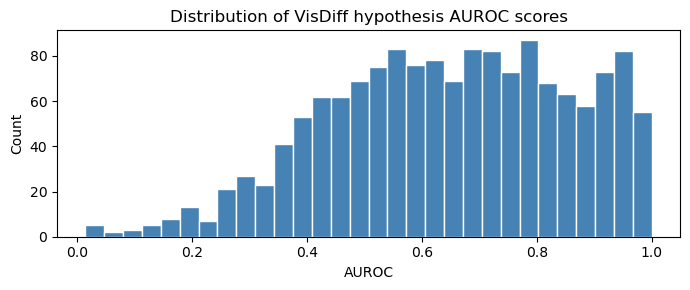

In [3]:
visdiff_df = pd.read_csv(VISDIFF_CSV)
visdiff_df["auroc"] = pd.to_numeric(visdiff_df["auroc"], errors="coerce")
visdiff_df["taxon_id"] = visdiff_df["taxon_id"].astype(str)

print(f"Loaded {len(visdiff_df)} hypotheses for {visdiff_df['taxon_id'].nunique()} species")
print(f"Columns: {list(visdiff_df.columns)}\n")

# ── Species summary ──────────────────────────────────────────────────────────
species_summary = (
    visdiff_df.groupby(["taxon_id", "species"])
    .agg(n_hypotheses=("difference", "count"), mean_auroc=("auroc", "mean"))
    .sort_values("mean_auroc", ascending=False)
    .reset_index()
)
display(species_summary)

# ── AUROC distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(visdiff_df["auroc"].dropna(), bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("AUROC")
ax.set_ylabel("Count")
ax.set_title("Distribution of VisDiff hypothesis AUROC scores")
plt.tight_layout()
plt.show()

## 3 — Reconstruct Image Groups (Group A / Group B)

Uses the project's scoring pipeline (`compute_site_scores` + `rank_image_groups`) to recover which sites ended up in each group for the VisDiff comparison. This loads feature data and fit results into memory.

> **If this section fails** (e.g. missing fit results, memory limits), the hypothesis bar charts in Section 5 still work — you just won't see the satellite image grids.

In [ ]:
# ── Import project modules (safe now that .env is loaded) ─────────────────────
# Patch set_start_method so config.py doesn't crash in a Jupyter kernel where
# the multiprocessing context may already be set.
import multiprocessing as _mp
_orig_ssm = _mp.set_start_method
def _safe_ssm(*a, **kw):
    try:
        _orig_ssm(*a, **kw)
    except RuntimeError:
        pass  # context already set — fine in a notebook
_mp.set_start_method = _safe_ssm

try:
    from sat_mmocc.config import default_image_backbone, default_sat_backbone
    from sat_mmocc.interpretability_utils import (
        compute_site_scores,
        load_fit_results,
        rank_image_groups,
        resolve_fit_results_path,
    )
    from sat_mmocc.utils import get_taxon_map

    IMAGE_BACKBONE = default_image_backbone
    SAT_BACKBONE = default_sat_backbone
    taxon_map = get_taxon_map()
    _PROJECT_IMPORTS_OK = True
    print(f"Image backbone:    {IMAGE_BACKBONE}")
    print(f"Sat backbone:      {SAT_BACKBONE}")
    print(f"Taxon map entries: {len(taxon_map)}")

except Exception as exc:
    _PROJECT_IMPORTS_OK = False
    warnings.warn(
        f"Could not import project modules ({exc}). "
        "Image-group reconstruction (Section 3) will be skipped; "
        "hypothesis bar charts will still work."
    )

finally:
    _mp.set_start_method = _orig_ssm  # restore original

Image backbone:    dinov2_vitb14
Sat backbone:      alphaearth
Taxon map entries: 3493


: 

In [ ]:

# ── Lazy image-group reconstruction ───────────────────────────────────────────
# Groups are loaded ON DEMAND (one species at a time) to avoid OOM crashes.
# A small LRU cache keeps the most-recently-viewed species in memory.

from functools import lru_cache

species_groups: dict = {}  # populated lazily on first access

if not _PROJECT_IMPORTS_OK:
    print("Skipping image-group reconstruction (project imports failed).")
    _RECONSTRUCTION_OK = False
else:
    _RECONSTRUCTION_OK = True

    def _load_groups_for_taxon(taxon_id: str) -> dict | None:
        """Load (standard + unique) groups for a single taxon. Returns None on failure."""
        tid = str(taxon_id)
        groups = {}
        display_name = None
        try:
            for mode in ("standard", "unique"):
                fit_path, res_mod, res_img, res_sat = resolve_fit_results_path(
                    tid, MODALITIES, IMAGE_BACKBONE, SAT_BACKBONE
                )
                fit_results = load_fit_results(fit_path)
                site_scores, display_name = compute_site_scores(
                    tid, res_mod, res_img, res_sat, fit_results
                )
                site_scores["image_path"] = site_scores["loc_id"].apply(
                    lambda lid: str(PNG_DIR / f"{lid}.png")
                )
                site_scores["image_exists"] = site_scores["image_path"].apply(
                    lambda p: Path(p).exists()
                )
                pos_df, neg_df = rank_image_groups(
                    site_scores,
                    res_mod,
                    mode=mode,
                    unique_weight=UNIQUE_WEIGHT,
                    top_k=TOP_K,
                    image_modality="sat",
                    test=False,
                )
                groups[mode] = (pos_df, neg_df)
            return {"groups": groups, "display_name": display_name}
        except FileNotFoundError as exc:
            warnings.warn(f"Skipping {tid}: {exc}")
            return None

    def get_species_data(taxon_id: str) -> dict | None:
        """Return cached groups dict for taxon_id, loading it if needed."""
        tid = str(taxon_id)
        if tid not in species_groups:
            result = _load_groups_for_taxon(tid)
            if result is not None:
                species_groups[tid] = result
        return species_groups.get(tid)

    # Validate that at least the first species can be loaded
    _first_available = species_summary["taxon_id"].astype(str).iloc[0]
    _test = get_species_data(_first_available)
    if _test:
        n_pos = len(_test["groups"]["standard"][0])
        n_neg = len(_test["groups"]["standard"][1])
        print(f"Lazy loading OK — test species '{_test['display_name']}': "
              f"{n_pos} pos, {n_neg} neg (standard)")
    else:
        print("Warning: could not load groups for the first species.")
    print(f"\n{len(species_summary)} species available (loaded on demand).")


## 4 — Visualization Helpers

In [ ]:
def load_thumb(path: str, size: Tuple[int, int] = THUMB_SIZE) -> np.ndarray | None:
    """Load an image as an RGB numpy array thumbnail, returning None on failure."""
    try:
        img = Image.open(path).convert("RGB").resize(size, Image.LANCZOS)
        return np.asarray(img)
    except Exception:
        return None


def plot_image_grid(
    image_paths: List[str],
    label: str,
    color: str,
    axes_row: list,
    n: int = N_IMAGES_DISPLAY,
) -> None:
    """Fill a row of axes with thumbnails from image_paths."""
    for col_idx, ax in enumerate(axes_row[:n]):
        if col_idx < len(image_paths):
            arr = load_thumb(image_paths[col_idx])
            if arr is not None:
                ax.imshow(arr)
                ax.set_title(
                    Path(image_paths[col_idx]).stem[:20], fontsize=6, color="dimgray"
                )
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
        else:
            ax.set_visible(False)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)


def plot_hypotheses_bar(
    ax: plt.Axes,
    taxon_id: str,
    n: int = N_HYPOTHESES,
    title: str | None = None,
) -> None:
    """Horizontal bar chart of top-N VisDiff hypotheses into axes *ax*."""
    df = (
        visdiff_df[visdiff_df["taxon_id"] == str(taxon_id)]
        .sort_values("auroc", ascending=False)
        .head(n)
    )
    if df.empty:
        ax.text(0.5, 0.5, "No hypotheses", ha="center", va="center")
        ax.axis("off")
        return

    auroc_vals = df["auroc"].values[::-1]
    labels = df["difference"].values[::-1]
    max_len = 55
    labels_disp = [
        (lbl if len(lbl) <= max_len else lbl[: max_len - 1] + "…") for lbl in labels
    ]

    cmap = plt.cm.RdYlGn
    colors = [cmap(v) for v in np.clip((auroc_vals - 0.4) / 0.4, 0, 1)]
    bars = ax.barh(range(len(labels_disp)), auroc_vals, color=colors, edgecolor="white")
    ax.set_yticks(range(len(labels_disp)))
    ax.set_yticklabels(labels_disp, fontsize=8)
    ax.set_xlabel("AUROC")
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlim(
        left=max(0, float(auroc_vals.min()) - 0.05),
        right=min(1.0, float(auroc_vals.max()) + 0.05),
    )
    if title:
        ax.set_title(title, fontsize=9)
    for bar, val in zip(bars, auroc_vals):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=7.5,
        )

In [ ]:

def plot_species_report(
    taxon_id: str,
    mode: str = "standard",
    n_images: int = N_IMAGES_DISPLAY,
    n_hyp: int = N_HYPOTHESES,
) -> None:
    """Combined figure: image grid (left) + hypothesis bar chart (right).

    If image groups were not loaded (project imports failed or species missing),
    shows only the hypothesis chart. Groups are loaded lazily on first access.
    """
    taxon_id = str(taxon_id)

    # ── Lazy load (evict all but the current species to save memory) ──────────
    if _RECONSTRUCTION_OK:
        # Keep only this species in the in-memory cache
        for old_tid in list(species_groups.keys()):
            if old_tid != taxon_id:
                del species_groups[old_tid]
        data = get_species_data(taxon_id)
    else:
        data = None

    # ── Determine display name ────────────────────────────────────────────────
    if data is not None:
        display_name = data["display_name"]
    else:
        names = visdiff_df.loc[visdiff_df["taxon_id"] == taxon_id, "species"]
        display_name = names.iloc[0] if not names.empty else taxon_id

    has_images = data is not None and mode in data["groups"]

    if has_images:
        pos_df, neg_df = data["groups"][mode]
        pos_paths = pos_df["image_path"].tolist()
        neg_paths = neg_df["image_path"].tolist()
        n_img_cols = n_images

        # ── Full layout: images (left) + hypotheses (right) ──────────────────
        fig = plt.figure(figsize=(n_img_cols * 2.0 + 8, max(6, 0.45 * n_hyp + 3)))
        fig.suptitle(
            f"{display_name}  (taxon {taxon_id}, mode={mode})",
            fontsize=13, fontweight="bold", y=1.00,
        )
        outer = gridspec.GridSpec(
            1, 2, figure=fig, width_ratios=[n_img_cols * 2, 8], wspace=0.35
        )
        left_gs = gridspec.GridSpecFromSubplotSpec(
            2, n_img_cols, subplot_spec=outer[0], hspace=0.08, wspace=0.05
        )
        for row_idx, (label, color, paths) in enumerate([
            ("Group A — Present", "#2196F3", pos_paths),
            ("Group B — Absent",  "#F44336", neg_paths),
        ]):
            axes_row = [fig.add_subplot(left_gs[row_idx, c]) for c in range(n_img_cols)]
            axes_row[0].set_ylabel(
                label, fontsize=9, color=color, fontweight="bold", rotation=90, labelpad=4
            )
            plot_image_grid(paths, label, color, axes_row, n=n_img_cols)

        ax_hyp = fig.add_subplot(outer[1])
    else:
        # ── Hypotheses-only layout ───────────────────────────────────────────
        fig, ax_hyp = plt.subplots(figsize=(9, max(3, 0.42 * n_hyp)))
        fig.suptitle(
            f"{display_name}  (taxon {taxon_id})",
            fontsize=13, fontweight="bold",
        )

    plot_hypotheses_bar(
        ax_hyp, taxon_id, n=n_hyp,
        title="Top VisDiff hypotheses (Group A > Group B)",
    )
    plt.tight_layout()
    plt.show()


## 5 — Per-Species Reports

Preview the first species, then use the interactive widget to flip through all of them.

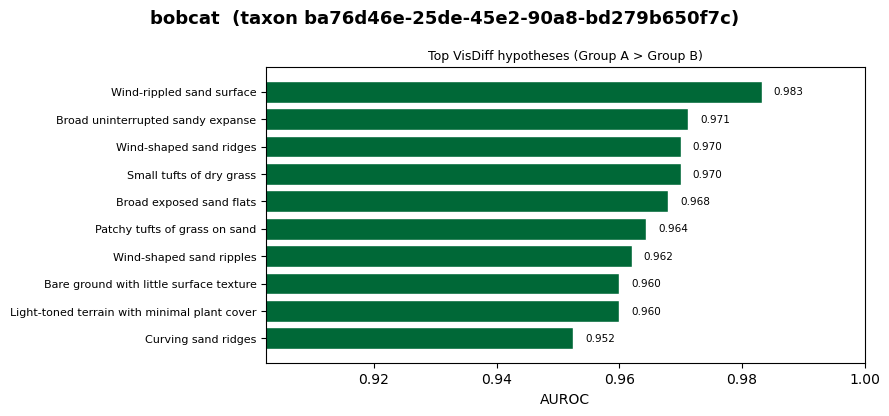

In [ ]:

# ── Static preview: first species ─────────────────────────────────────────────
_first_id = species_summary["taxon_id"].astype(str).iloc[0]
plot_species_report(_first_id, mode="standard")


In [ ]:
# ── Interactive dropdown (requires ipywidgets) ────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display

    # Build dropdown options from all species in the CSV
    _all_ids = species_summary["taxon_id"].astype(str).tolist()
    _all_names = species_summary["species"].tolist()
    dropdown_options = [
        (f"{name} ({tid})", tid) for name, tid in zip(_all_names, _all_ids)
    ]
    mode_options = ["standard", "unique"]

    species_dropdown = widgets.Dropdown(
        options=dropdown_options,
        description="Species:",
        layout=widgets.Layout(width="450px"),
    )
    mode_dropdown = widgets.Dropdown(
        options=mode_options,
        value="standard",
        description="Mode:",
        layout=widgets.Layout(width="200px"),
    )
    out = widgets.Output()

    def _on_change(_change=None):
        out.clear_output(wait=True)
        with out:
            plot_species_report(species_dropdown.value, mode=mode_dropdown.value)

    species_dropdown.observe(_on_change, names="value")
    mode_dropdown.observe(_on_change, names="value")

    controls = widgets.HBox([species_dropdown, mode_dropdown])
    ipy_display(widgets.VBox([controls, out]))

    # Trigger initial render
    _on_change()

except ImportError:
    print("ipywidgets not available — rendering first 5 species statically.")
    for _tid in species_summary["taxon_id"].astype(str).tolist()[:5]:
        plot_species_report(_tid)

## 6 — Batch Render (optional)

Uncomment and run to produce a static report for every species.

In [ ]:
# Uncomment to render all species:
# for _tid in species_summary["taxon_id"].astype(str).tolist():
#     plot_species_report(_tid, mode="standard")